# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1. 

In [1]:
import numpy as np
from scipy.io.wavfile import read
from scipy import signal
import librosa
from librosa import feature, load, frames_to_time
import matplotlib.pyplot as plt
from math import ceil, log2, sqrt
import pandas as pd


## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [2]:
# your code here
def my_stft(audio_input, frame_size, sampling_rate = 44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    if sqrt(frame_size) % 2 == 0:
        frame_length = frame_size
  
    else:
        frame_length = 2 ** ceil(log2(frame_size))

    
    # Define hop size is half the frame size

    hop_length = int(frame_length/2)


    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    n_mbins = (len(audio_input) - frame_length) // hop_length + 1
    n_mbins = int(n_mbins)
    

    # Define total number of frequency bins
    n_kbins = (frame_length // 2) + 1

    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np.zeros((n_mbins, n_kbins), dtype=complex)

    # Define window
    window = np.hanning(frame_length)

    # Iterate through signal by frame
    for m in range(n_mbins):
        # index into the frame, apply window, apply fft over the frame, store in matrix
        frame = (audio_input[m*hop_length:(m*hop_length)+ frame_length]) * window
        spectrum = np.fft.rfft(frame)

        stft_matrix[m, :] = spectrum

     

    return stft_matrix




#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

/opt/miniconda3/envs/AudioTechII/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


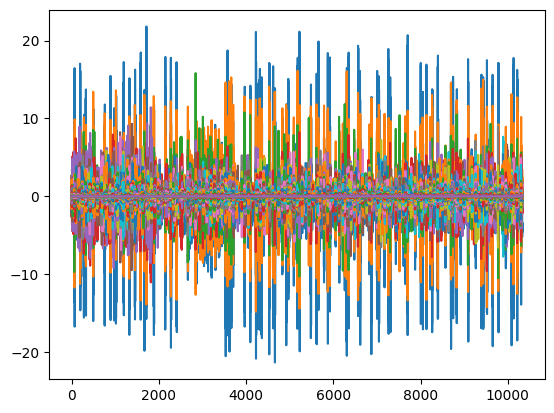

In [12]:
fs, x = read('../audio/hiphop.00000.wav')
x = x/abs(x).max()
fs2, x2 = read('../audio/country.00000.wav')
x2 = x2/abs(x2).max()

STFT_proof1 = my_stft(x, 128, fs)
STFT_proof2 = my_stft(x2, 128, fs2)

plt.plot(STFT_proof1)



#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


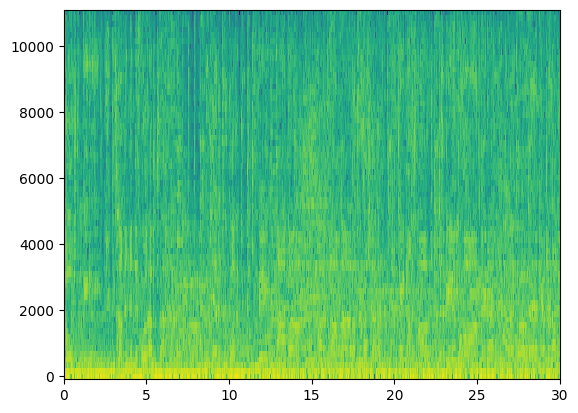

In [13]:
# your code here
def plot_spectrogram(stft_matrix, frame_size, sampling_rate):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes
    num_frames =  stft_matrix.shape[0] # total number of frames

    
    hop_size =   frame_size // 2 # recall it was 50% of the frame size
    duration =  (num_frames * hop_size) // sampling_rate  # find duration

    

    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    time_axis = np.linspace(0,duration, num_frames)
    # Ditto for frequency axis according to the number of bins
    freq_axis = np.linspace(0, sampling_rate // 2, np.size(stft_matrix, axis=1))
    #freq_axis = frame_size /2

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    


    plt.pcolormesh(time_axis, freq_axis, magnitude_db)
    plt.colorbar

    

    

    




plot_spectrogram(STFT_proof2, 128, fs)

Plot the spectrogram of the country and hiphop audio files

## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

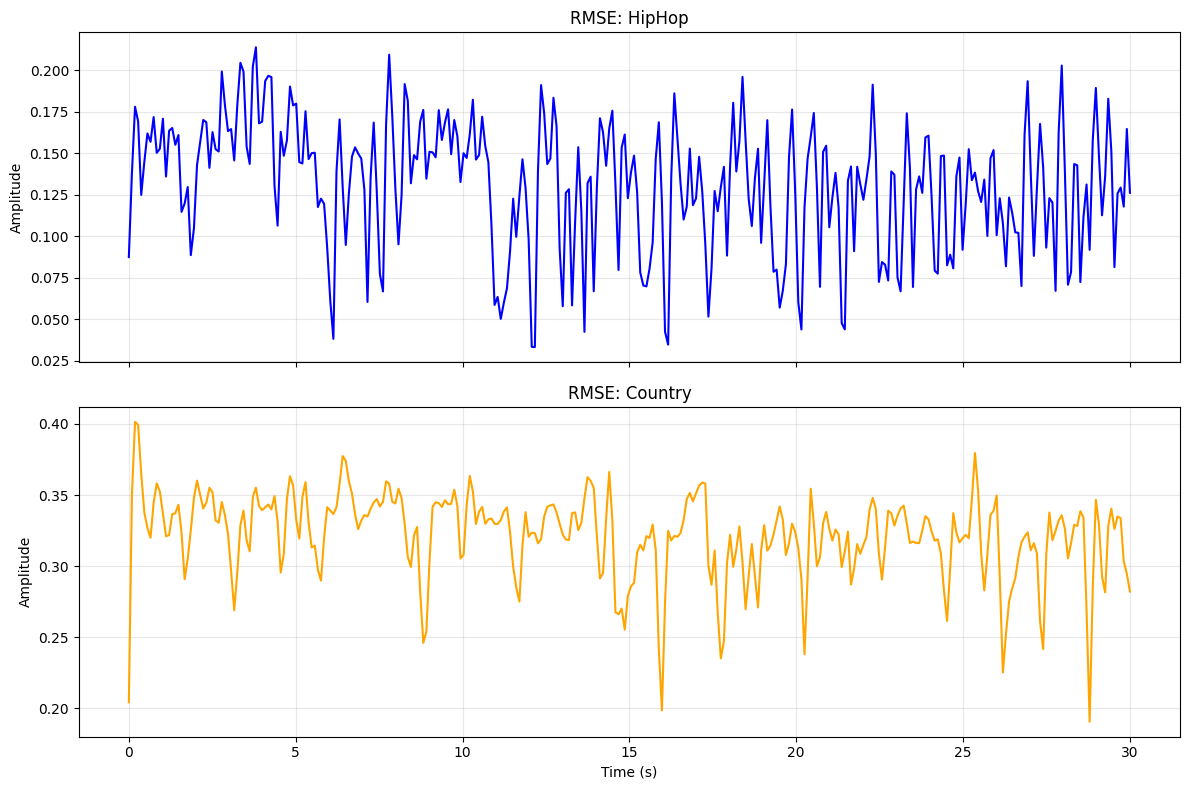

In [5]:
import matplotlib.pyplot as plt
import librosa

def plot_comparison(x1, x2, sr, label1="HipHop", label2="Country"):
    # 1. Calculate RMSE for both
    # Note: hop_length and frame_length should match your previous analysis
    hop_length = 2048
    frame_length = 4096
    
    rmse1 = librosa.feature.rms(y=x1, frame_length=frame_length, hop_length=hop_length).flatten()
    rmse2 = librosa.feature.rms(y=x2, frame_length=frame_length, hop_length=hop_length).flatten()
    
    # 2. Create time axes for both (in case they have different lengths)
    t1 = librosa.frames_to_time(range(len(rmse1)), sr=sr, hop_length=hop_length)
    t2 = librosa.frames_to_time(range(len(rmse2)), sr=sr, hop_length=hop_length)
    
    # 3. Create a figure with 2 subplots (2 rows, 1 column)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot first genre
    ax1.plot(t1, rmse1, color='blue', label=label1)
    ax1.set_title(f'RMSE: {label1}')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True, alpha=0.3)
    
    # Plot second genre
    ax2.plot(t2, rmse2, color='orange', label=label2)
    ax2.set_title(f'RMSE: {label2}')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Amplitude')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout() # Prevents labels from overlapping
    plt.show()

# To run it:
plot_comparison(x, x2, fs)

Your RMSE explantion here!

RMSE (or Root Mean Square Energy) is the measure of the average of a signal's absolute intensity over a given period (typically 100-500ms). This is typically more useful than just the energy of the signal, and tells us how "loud" a signal is at any given moment. This metric is directly correlated with dynamics in a piece of music, so may serve as a relevant way to distinguish between genres that have different compositional structures. 

Text(0, 0.5, 'Hz')

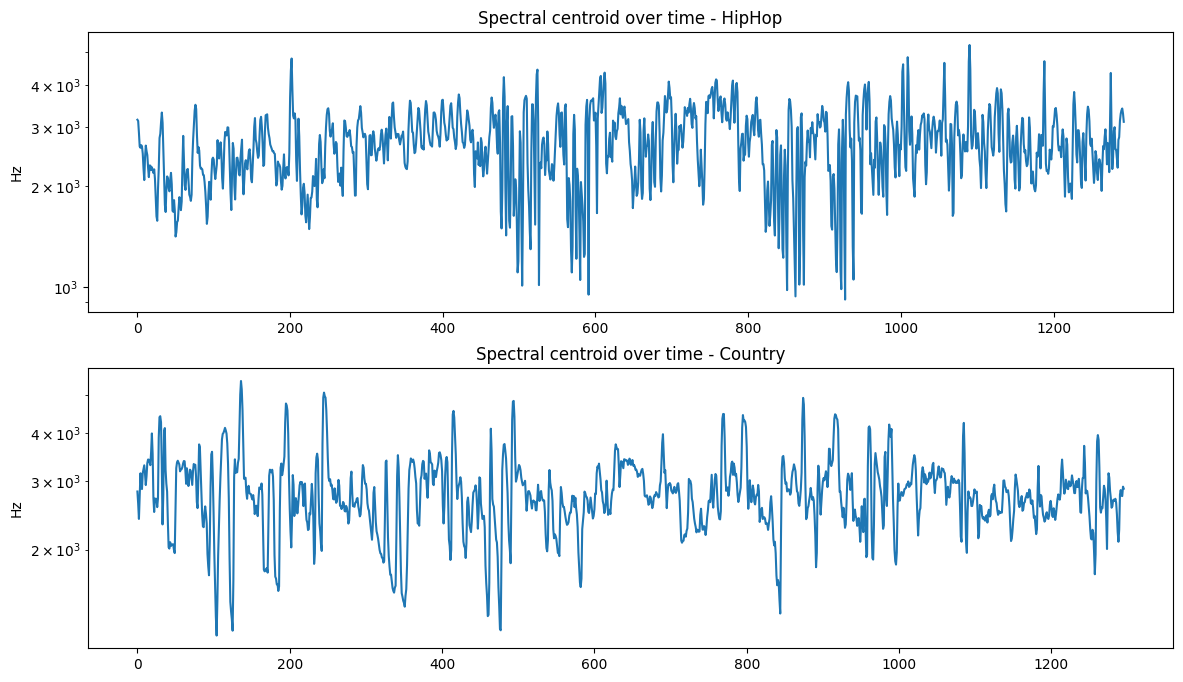

In [6]:
# Spectral Centroid for hiphop
hhSpec = librosa.feature.spectral_centroid(y=x.astype(float), sr=fs)

# Spectral Centroid for country
ccSpec = librosa.feature.spectral_centroid(y=x2.astype(float), sr=fs2)

# plotting

plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.semilogy(hhSpec[0])
plt.title('Spectral centroid over time - HipHop')
plt.ylabel('Hz')
plt.subplot(2,1,2)
plt.semilogy(ccSpec[0])
plt.title('Spectral centroid over time - Country')
plt.ylabel('Hz')

Your centroid explanation here!

Spectral centroid is a measure of the distribution of frequencies over time. Perceptually, it tells us whether the timbre of a signal is more "nasally" (high frequencies), or "dull" (low frequencies). Typically, this feature is heavily impacted by the instrumentation of a piece, so can serve as a meaningful way to discriminate between songs with differing instruments.

Text(0, 0.5, 'Flux')

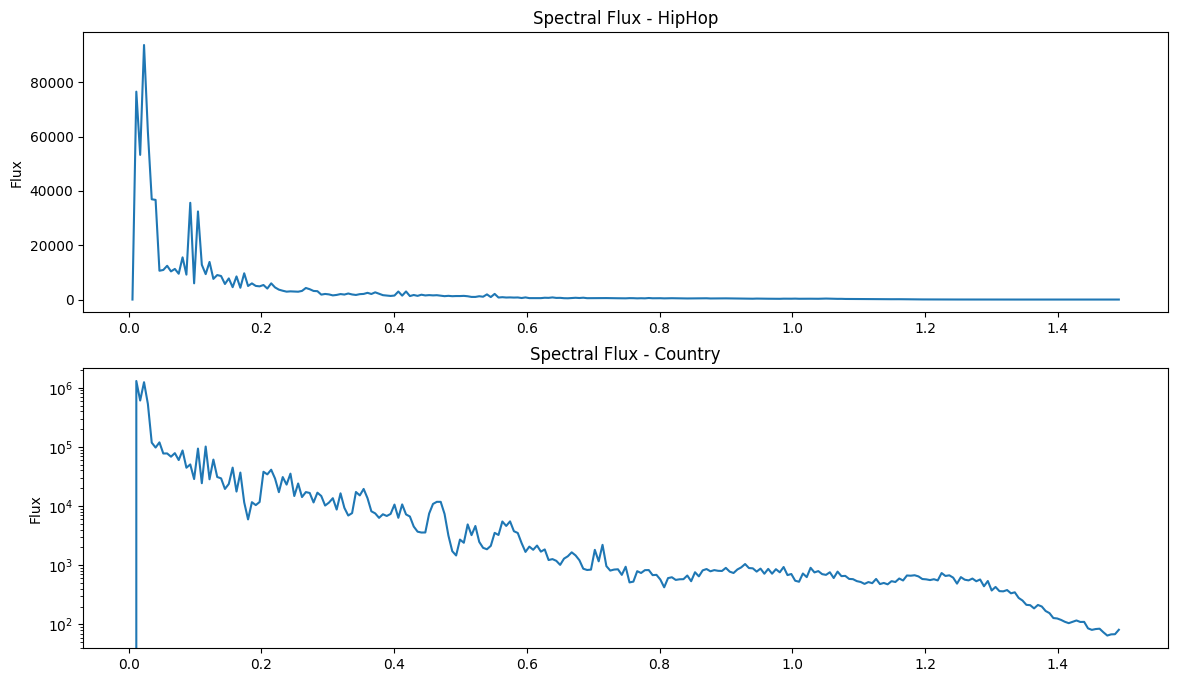

In [7]:
# spectral flux for hiphop
frame_length = 512
hop_length = 128

hh_matrix = my_stft(x, frame_length)

hh_magnitude = np.abs(hh_matrix)

# Frame-to-frame difference
hh_diff = np.diff(hh_magnitude, axis=1)

# Square and sum across frequency bins
hh_flux = np.sum(hh_diff**2, axis=0)

# Pad so output matches frame count
hh_flux = np.concatenate(([0], hh_flux))

frames = range(1,len(hh_flux)+1) #vector of frames as iterable
hh_t = frames_to_time(frames, sr=fs, hop_length=hop_length)


# spectral flux for country

cc_matrix = my_stft(x2, frame_length)

cc_magnitude = np.abs(cc_matrix)

# Frame-to-frame difference
cc_diff = np.diff(cc_magnitude, axis=1)

# Square and sum across frequency bins
cc_flux = np.sum(cc_diff**2, axis=0)

# Pad so output matches frame count
cc_flux = np.concatenate(([0], cc_flux))

frames = range(1,len(cc_flux)+1) #vector of frames as iterable
cc_t = frames_to_time(frames, sr=fs2, hop_length=hop_length)

plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.plot(hh_t, hh_flux)
plt.title('Spectral Flux - HipHop')
plt.ylabel('Flux')
plt.subplot(2,1,2)
plt.semilogy(cc_t, cc_flux)
plt.title('Spectral Flux - Country')
plt.ylabel('Flux')




# plotting

Your spectral flux explanation here!

Spectral flux is the measurement of change in the power spectrum of frequencies in a signal over time. For signals with sharply changing timbres, spectral flux can give us a lot of information about where those changes occur — this is typically more relevant for speech than music, since it often has a greater degree of spectral flux. 

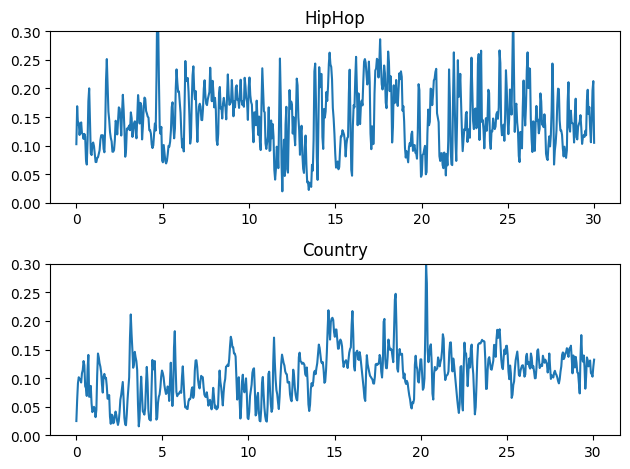

In [8]:
# ZCR for hiphop
a = librosa.feature.zero_crossing_rate(x.astype(float), hop_length=1024)
ax1 = np.linspace(0,len(x)/fs,len(a[0]))
# ZCR for country
b = librosa.feature.zero_crossing_rate(x2.astype(float), hop_length=1024)
ax2 = np.linspace(0,len(x2)/fs2,len(b[0]))

# plotting
plt.subplot(2,1,1)
plt.plot(ax1, a[0])
plt.ylim(0,0.3)
plt.title('HipHop')
plt.subplot(2,1,2)
plt.plot(ax2,b[0])
plt.ylim(0,0.3)
plt.title('Country')
plt.tight_layout()








Your ZCR explanation here!

ZCR, or the Zero-Crossing Rate, is the measure of how often a given signal changes signs between negative and positive magnitude. It's an easy way to roughly calculate the frequency content of a signal, with a higher ZCR typically corresponding to higher frequencies. Also, it can give us an idea as to the harmonicity of a signal, since if the ZCR is roughly periodic we can expect the signal to be quite periodic as well.

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

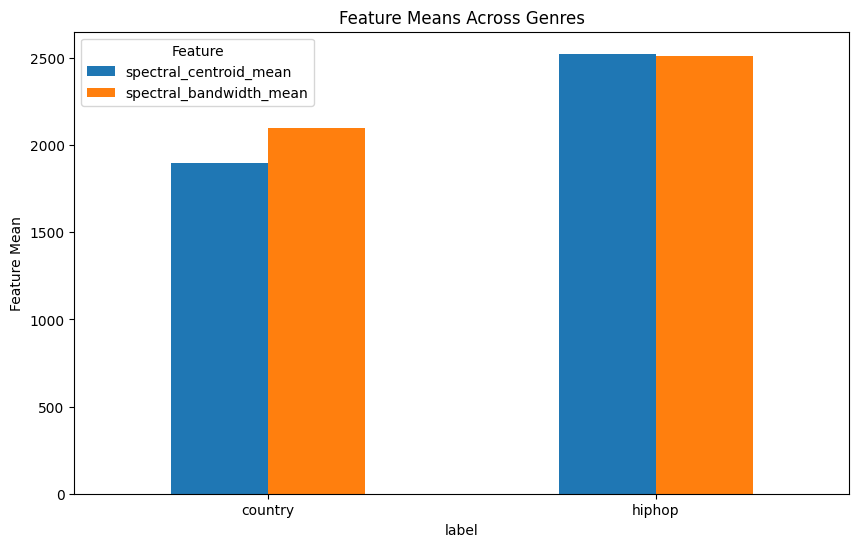

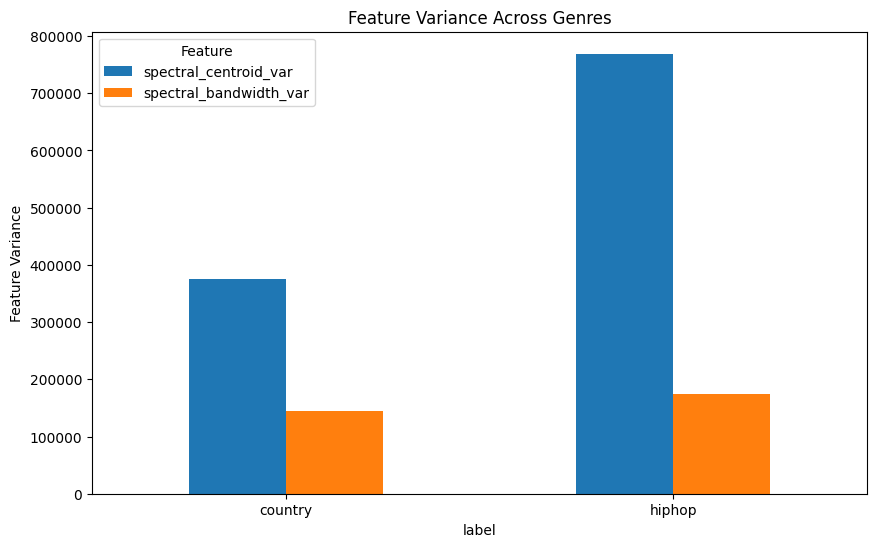

<AxesSubplot: title={'center': 'harmony_mean'}, xlabel='label'>

<Figure size 640x480 with 0 Axes>

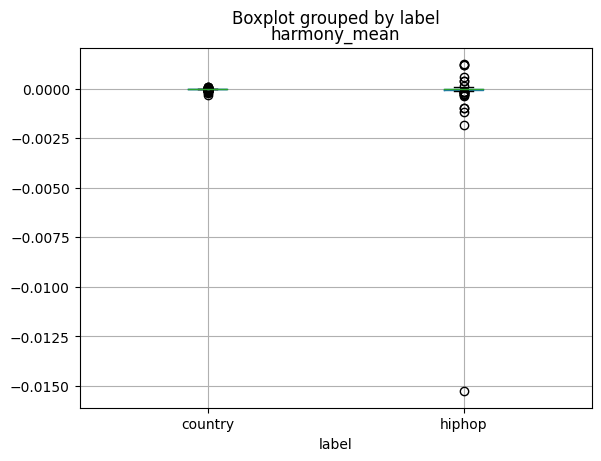

In [9]:
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt, matplotlib


data = pd.read_csv('../Datasets/Features_30_sec.csv')

dataFilt = data[data['label'].isin(['country', 'hiphop'])]

grouped = dataFilt.groupby("label").mean(numeric_only=True)
features = [
    "spectral_centroid_mean",
    'spectral_bandwidth_mean'
   
    
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Feature Mean by label')
plt.ylabel("Feature Mean")
plt.title("Feature Means Across Genres")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

grouped2 = dataFilt.groupby("label").mean(numeric_only=True)
features2 = [
    'spectral_centroid_var',
    "spectral_bandwidth_var",
    
   
    
]

grouped_features2 = grouped2[features2]
grouped_features2.plot.bar(figsize=(10, 6), title='Feature Variance by label')
plt.ylabel("Feature Variance")
plt.title("Feature Variance Across Genres")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()



plt.figure()
dataFilt.boxplot(column="harmony_mean", by="label")


 

### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

In [10]:
dataFeatures = dataFilt[['label', 'spectral_centroid_mean',
    'spectral_bandwidth_mean', 'spectral_centroid_var',
    "spectral_bandwidth_var", "harmony_mean"]]


label = pd.get_dummies(dataFeatures['label'], drop_first=True)
spectral_centroid_mean = pd.get_dummies(dataFeatures['spectral_centroid_mean'], drop_first=True)
spectral_bandwidth_mean = pd.get_dummies(dataFeatures['spectral_bandwidth_mean'], drop_first=True)
spectral_centroid_var = pd.get_dummies(dataFeatures['spectral_centroid_var'], drop_first=True)
spectral_bandwidth_var = pd.get_dummies(dataFeatures['spectral_bandwidth_var'], drop_first=True)
harmony_mean = pd.get_dummies(dataFeatures['harmony_mean'], drop_first=True)

dataDummy = pd.concat([label,spectral_centroid_mean, spectral_bandwidth_mean, spectral_centroid_var, spectral_centroid_var, harmony_mean], axis=1)

normalized_df=(dataDummy-dataDummy.mean())/dataDummy.std()


categories = dataDummy.iloc[:,1:]
predictors = dataDummy.iloc[:,0]
pred_train, pred_test, cat_train, cat_test = train_test_split(categories, predictors, test_size = .3, random_state=25)

model = LogisticRegression(solver='lbfgs') #for simple binary logistic regression we can use all default parameters
model.fit(pred_train, cat_train)
predictions = model.predict(pred_test)

coeffs = pd.Series(model.coef_[0])
coeffs = dict(zip(dataDummy.columns[1:], model.coef_[0]))





### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

In [11]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(cat_test, predictions)#parameters are y_truth (i.e.,Ground truth (correct) target values), y_pred (i.e., predicted values from model).

pd.DataFrame(cm, columns=['Died','Survived'], index=['Predicts_died','Predicts_survived'])

accuracy

NameError: name 'accuracy' is not defined

Your model interpretation here!

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content